In [1]:
import numpy as np
import pandas as pd
from importlib import reload
import NpAutograd as npa
from NpAutograd import sigmoid, relu, BCELoss, leaky_relu, logloss, softmax, rmse
from NeuralNetwork import NeuralNetwork
from TrainHelpers import batcher, get_metrics, one_hot
from VecOptim import SGD, MomentumSGD, MomentumSGDW, AdaGrad, AdaGradW, RMSProp, RMSPropW, Adam, AdamW
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [2]:
def cosine_annealing_schedule(epochs: int, batchsize: int, dataset_length: int, warmup_steps: float = 0.1):
    num_steps = np.ceil(dataset_length / batchsize) * epochs
    num_warmup = warmup_steps * num_steps
    def schedule(t):
        if t < num_warmup:
            return t / num_warmup
        else:
            return np.cos((t - num_warmup) / (num_steps - num_warmup) * np.pi / 2)
    return schedule

In [3]:
X = np.linspace(-1, 1, 1_000).reshape(-1, 1)
Y = X**2 + X #Same toy problem as before but now with the power of universal function approximators

In [4]:
neural_net = NeuralNetwork(1,1, activation=sigmoid)

In [5]:
num_epochs = 400
batch_size = 100
schedule = cosine_annealing_schedule(num_epochs, batch_size, len(X))
optim = AdamW(neural_net.get_params(), lr=1e-3, lr_func=schedule, reg_type="l2", reg_param=1e-6, momentum=0.9, beta2=0.99)

In [6]:
losses=[]
for i in range(num_epochs):
    batch = batcher(X, Y, batch_size)
    for batch_data, batch_lbl in batch:
        preds = neural_net(batch_data)
        loss = rmse(preds, batch_lbl)
        loss.backward()
        #print(np.any(np.isnan(preds.grad)))
        optim.step()
        losses.append(loss.v)
    if i % 10 == 0:
        print(f"Epoch {i}: Loss {loss.v}")

Epoch 0: Loss 2.6021409431141658
Epoch 10: Loss 2.0302732654735034
Epoch 20: Loss 0.3983611390854325
Epoch 30: Loss 0.7658145015669172
Epoch 40: Loss 0.5612724851004722
Epoch 50: Loss 0.3375777595459072
Epoch 60: Loss 0.24364312361720195
Epoch 70: Loss 0.1434486641474231
Epoch 80: Loss 0.14320529143079555
Epoch 90: Loss 0.12364206877660121
Epoch 100: Loss 0.10296006065438765
Epoch 110: Loss 0.09615515396326194
Epoch 120: Loss 0.11238901270168324
Epoch 130: Loss 0.11098453221488337
Epoch 140: Loss 0.10761704381338373
Epoch 150: Loss 0.0754028296566007
Epoch 160: Loss 0.10694788416286208
Epoch 170: Loss 0.07607842288789214
Epoch 180: Loss 0.06660649695978105
Epoch 190: Loss 0.09391148879169285
Epoch 200: Loss 0.06529555301611026
Epoch 210: Loss 0.07559434196287743
Epoch 220: Loss 0.07228088702712308
Epoch 230: Loss 0.05556105165692835
Epoch 240: Loss 0.07388303436461816
Epoch 250: Loss 0.05975407051115563
Epoch 260: Loss 0.05971948335990606
Epoch 270: Loss 0.0638307640067546
Epoch 280: L

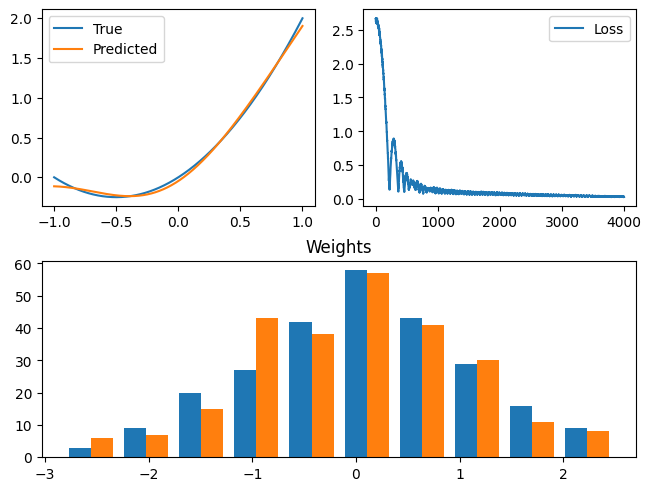

In [7]:
fig, ax = plt.subplot_mosaic([['left', 'right'],['bottom', 'bottom']],
                             constrained_layout=True)
ax['left'].plot(X, Y, label="True")
ax['left'].plot(X, neural_net(X).v, label="Predicted")
ax['left'].legend()
ax['right'].plot(losses, label="Loss")
ax['right'].legend()
ax['bottom'].hist([param.v.flatten() for param in neural_net.get_params()], bins=10)
ax['bottom'].set_title("Weights")
plt.show()

In [8]:
mnist_train = pd.read_csv("data/mnist_train.csv", header=None).to_numpy(dtype=np.float32)
train_labels, train_data = mnist_train[:,0], mnist_train[:,1:]
train_data = train_data / 255.
train_labels = one_hot(train_labels.astype(np.int32), 10)
test_data = pd.read_csv("data/mnist_test.csv", header=None).to_numpy(dtype=np.float32)
test_labels, test_data = test_data[:,0], test_data[:,1:]
test_data = test_data / 255.
test_labels = one_hot(test_labels.astype(np.int32), 10)

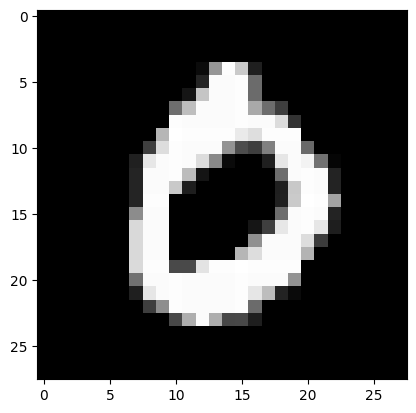

In [17]:
#Helpers to run test in a fast and efficient way
colors = ["blue", "red", "orange", "green", "purple"]
labels = ["SGD", "Momentum SGD", "AdaGrad", "RMSProp", "Adam"]
optimizers = [SGD, MomentumSGD, AdaGrad, RMSProp, Adam]
arglist = [{"lr":1e-3},
           {"momentum":0.9, "lr":1e-1},
           {"eps":1e-12, "momentum":0.9, "lr":1e-3},
           {"eps":1e-12, "momentum":0.9, "lr":1e-3},
           {"eps":1e-12, "momentum":0.9, "beta2":0.99, "lr":1e-3}]
reg_types = ["L1", "L2", "FLinf", "Linf"]
reg_params = [1e-6, 1e-6, 1e-2, 1e-3]
def run_test(optim, reg_type, reg_param, epochs=50, batch_size=256, **kwargs):
    neural_net = NeuralNetwork(784, 10, activation=leaky_relu)
    schedule = cosine_annealing_schedule(epochs, batch_size, len(train_data))
    optimizer = optim(neural_net.get_params(), lr_func=schedule, reg_type=reg_type, reg_param=reg_param, **kwargs)
    losses = []
    for i in range(epochs):
        batch = batcher(train_data, train_labels, batch_size)
        for batch_data, batch_lbl in batch:
            logits = neural_net(batch_data)
            loss = logloss(logits, batch_lbl)
            loss.backward()
            optimizer.step()
            losses.append(loss.v)
        if i % 10 == 0:
            print(f"Epoch {i}: Loss {loss.v}")
    stats = get_metrics(softmax(neural_net(test_data)).v, test_labels)
    print(f"Confusion Matrix:\n{stats['confusion_matrix']}\n {stats['micro_avg']}")
    return losses, [param.v.flatten() for param in neural_net.get_params()]

Running SGD with reg type L1 and reg param 1e-06
Epoch 0: Loss 44.74239583339752
Epoch 10: Loss 21.864685718771643
Epoch 20: Loss 20.969646154828954
Epoch 30: Loss 15.608586675934548
Epoch 40: Loss 13.507498514682553
Confusion Matrix:
[[   0    0   86   25    1  451  158   60  199    0]
 [   1 1062   13    6    0   14    4    4   31    0]
 [   0   13  886   18   20    7   23   23   42    0]
 [   0    7   42  892    1   26    6   22   14    0]
 [   0    6   11    4  889    9   23   10   30    0]
 [   0    8    9  133   22  506   59   21  134    0]
 [   0    7   29    0   17   16  879    4    6    0]
 [   0   27   29    4   20    6    2  930   10    0]
 [   0   18   18   36   23   28   29   22  799    1]
 [   2    4   11   25  600   41    8  214  104    0]]
 {'accuracy': np.float64(0.6843), 'precision': np.float64(0.6843), 'recall': np.float64(0.6843), 'f1': np.float64(0.6843)}
Running Momentum SGD with reg type L1 and reg param 1e-06
Epoch 0: Loss 35.758616996193275
Epoch 10: Loss 32.81

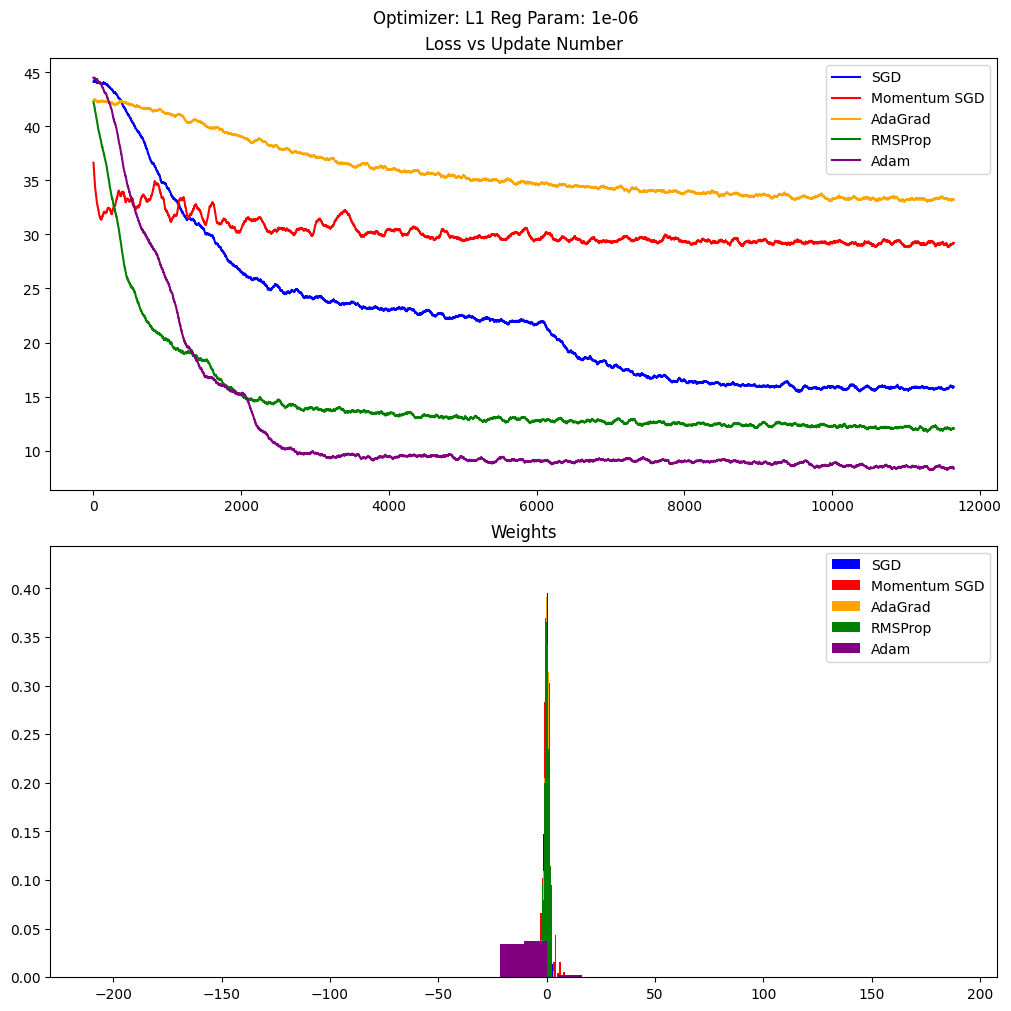

Running SGD with reg type L2 and reg param 1e-06
Epoch 0: Loss 39.77180757116475
Epoch 10: Loss 26.655771841594362
Epoch 20: Loss 21.5865221333171
Epoch 30: Loss 27.694089213823613
Epoch 40: Loss 25.41699226266034
Confusion Matrix:
[[ 936    1   19   18    0    0    0    5    0    1]
 [   0 1101   12   17    0    0    0    5    0    0]
 [  25   19  918   44    0    0    0   25    1    0]
 [  21    9   31  916    0    0    0   30    1    2]
 [  90   49  389  154    0    0    0  291    1    8]
 [ 150   79   49  531    2    0    1   76    1    3]
 [ 160   20  734   39    0    0    0    4    0    1]
 [   8   21   38   22    0    0    0  935    3    1]
 [  85  107  177  451    0    0    0  146    3    5]
 [  40   10  161  205    2    0    0  590    0    1]]
 {'accuracy': np.float64(0.481), 'precision': np.float64(0.481), 'recall': np.float64(0.481), 'f1': np.float64(0.481)}
Running Momentum SGD with reg type L2 and reg param 1e-06
Epoch 0: Loss 26.428728698871065
Epoch 10: Loss 22.873068802

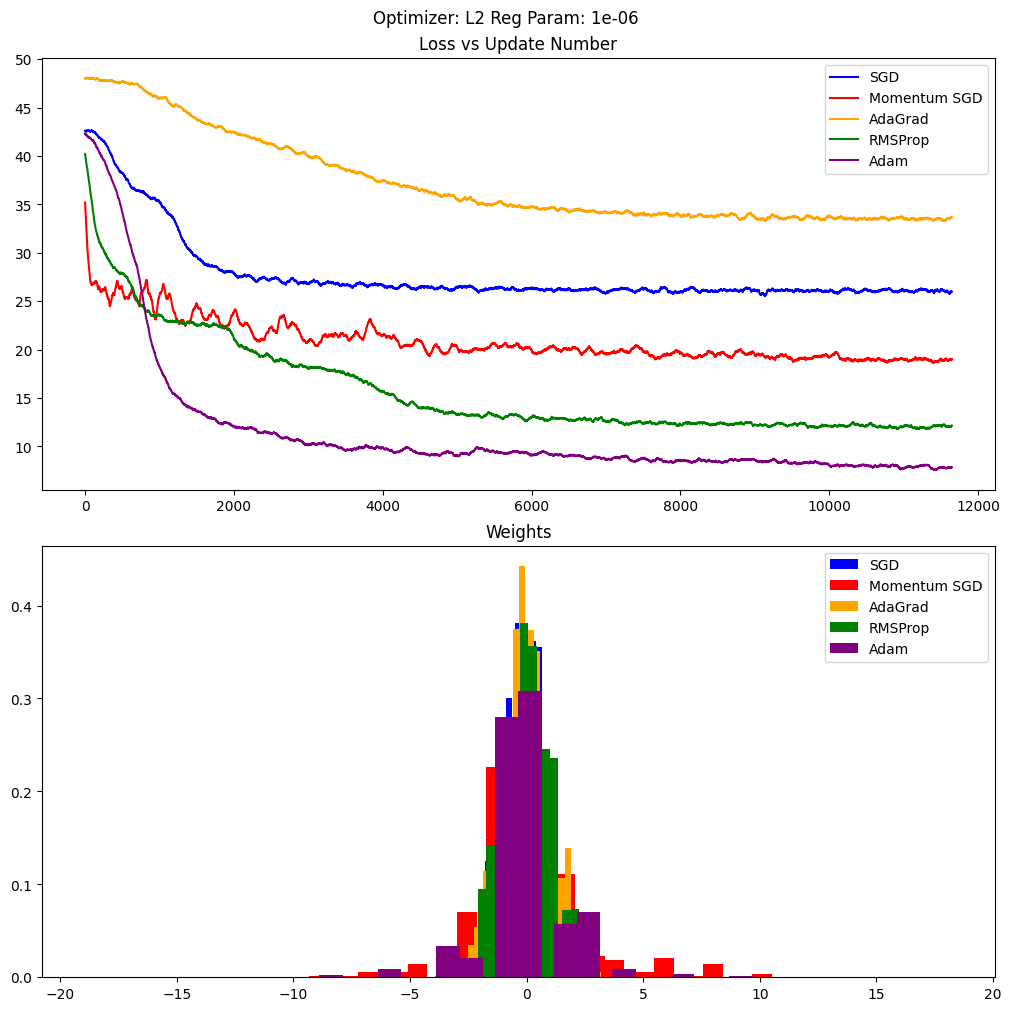

Running SGD with reg type FLinf and reg param 0.01
Epoch 0: Loss 47.21467356299623
Epoch 10: Loss 24.22098297765118
Epoch 20: Loss 23.176945414277892
Epoch 30: Loss 26.8297313979254
Epoch 40: Loss 23.244520076340393
Confusion Matrix:
[[931   0  17   1   1  16   0   2  10   2]
 [  5   0 198   8   0  82   0  14 820   8]
 [ 18   0 902   2   0  14   0  27  53  16]
 [ 52   0 204   7   3 392   0  26 288  38]
 [ 14   6  34   1   0  12   0  65  92 758]
 [ 54   0  34   3   0 678   0  34  72  17]
 [106   0 486   3   0 146   0   6  89 122]
 [  6   3  27   1   3   8   0 892  35  53]
 [ 19   0  28   4   0  47   0  24 811  41]
 [  9   1  18   0   0  31   0  52  28 870]]
 {'accuracy': np.float64(0.5091), 'precision': np.float64(0.5091), 'recall': np.float64(0.5091), 'f1': np.float64(0.5091)}
Running Momentum SGD with reg type FLinf and reg param 0.01
Epoch 0: Loss 29.405298159936677
Epoch 10: Loss 36.014290293485885
Epoch 20: Loss 32.02507110432355
Epoch 30: Loss 24.529343118268688
Epoch 40: Loss 20.

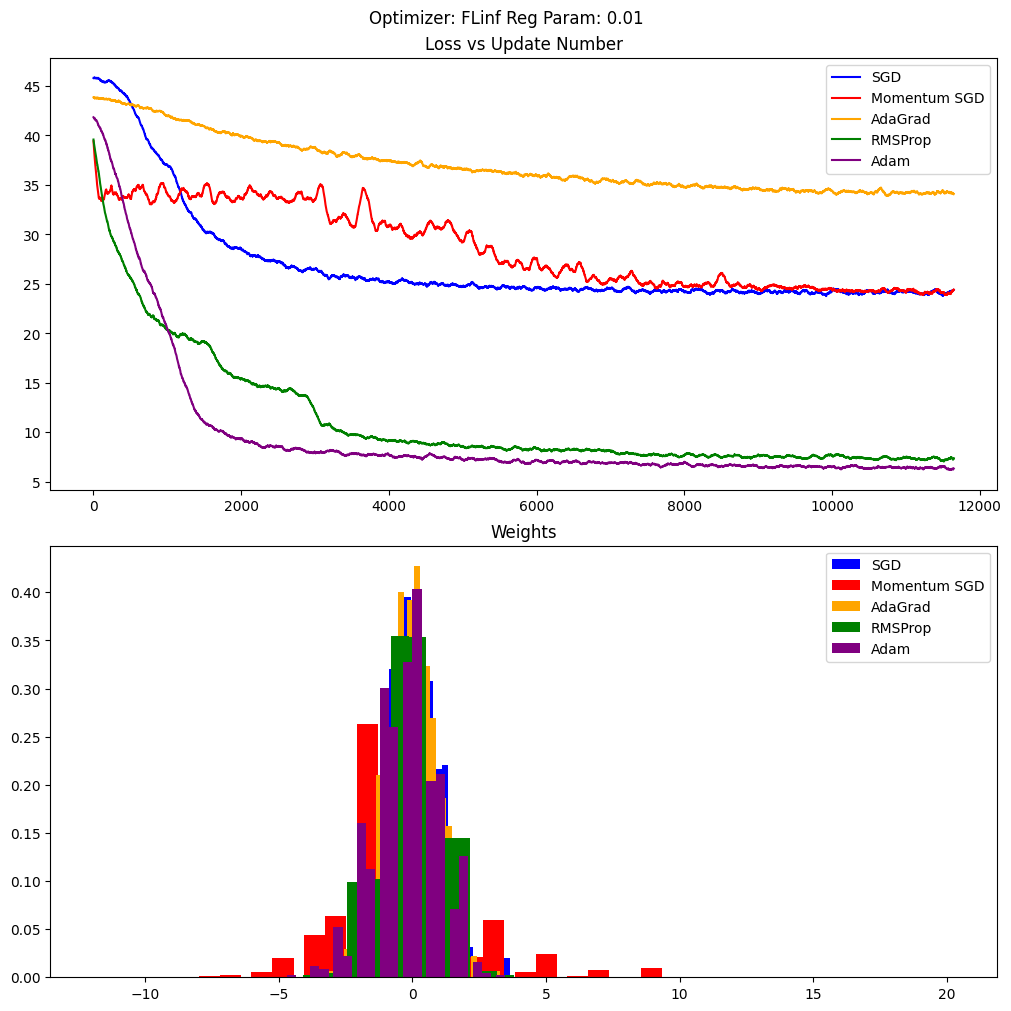

Running SGD with reg type Linf and reg param 0.001
Epoch 0: Loss 47.03759651641331
Epoch 10: Loss 37.086635584607926
Epoch 20: Loss 28.68138650208449
Epoch 30: Loss 28.51450998118732
Epoch 40: Loss 32.048966730673264
Confusion Matrix:
[[   0    4    0    0   24  853    1    0   62   36]
 [   0 1091    0    0    1    7    1    0   35    0]
 [   0   79    1    0   86   60    1    0  754   51]
 [   0   17    0    0    8  578    6    1  369   31]
 [   0   11    0    0  893   12    0    0   22   44]
 [   0   18    0    0   41  741    3    0   73   16]
 [   0   38    0    0  400  291    0    0  208   21]
 [   0   44    0    0   95   29    9    0  108  743]
 [   0   20    0    0   13   50    0    0  866   25]
 [   0    9    0    0   95   28    1    0   33  843]]
 {'accuracy': np.float64(0.4435), 'precision': np.float64(0.4435), 'recall': np.float64(0.4435), 'f1': np.float64(0.4435)}
Running Momentum SGD with reg type Linf and reg param 0.001
Epoch 0: Loss 35.72101855682507
Epoch 10: Loss 28.7

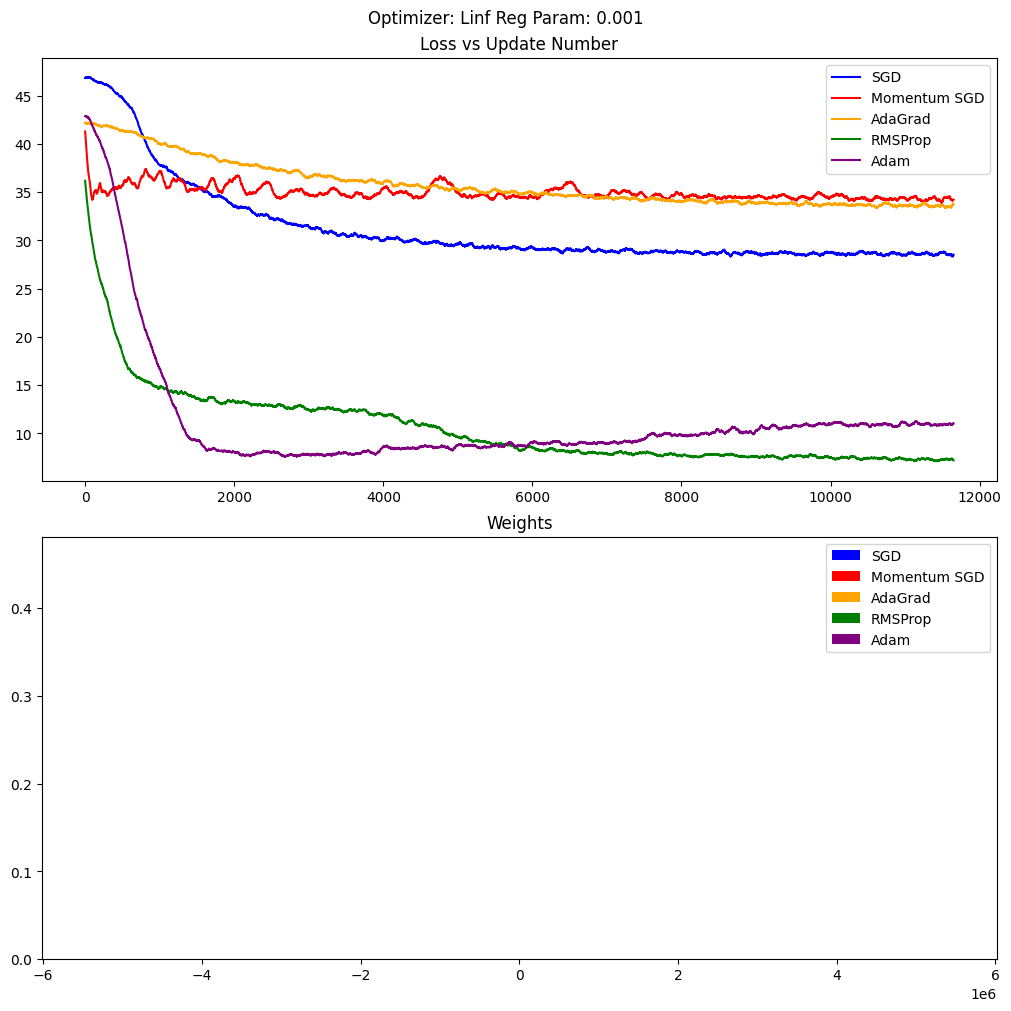

In [21]:
for reg_type, reg_param in zip(reg_types, reg_params):
    fig, axs = plt.subplots(2, figsize=(10,10), constrained_layout=True)
    for optimizer, color, label, kwargs in zip(optimizers, colors, labels, arglist):
        print(f"Running {label} with reg type {reg_type} and reg param {reg_param}")
        losses, params = run_test(optimizer, reg_type, reg_param, epochs=50, **kwargs)
        losses = np.array(losses)
        smoothed_losses = (losses.cumsum()[100:] - losses.cumsum()[:-100])/100
        axs[0].plot(smoothed_losses, color=color, label=label)
        axs[1].hist(params, color=(color, color), label=label, bins=15, density=True)
    axs[0].legend()
    axs[0].set_title(f"Loss vs Update Number")
    axs[1].legend()
    axs[1].set_title(f"Weights")
    fig.suptitle(f"Optimizer: {reg_type} Reg Param: {reg_param}")
    plt.show()

Running SGD with reg type L1 and reg param 1e-06
Epoch 0: Loss 46.90200322498132
Epoch 10: Loss 33.604837274317156
Epoch 20: Loss 31.489975489112624
Epoch 30: Loss 22.67741327713223
Epoch 40: Loss 23.296484341396734
Confusion Matrix:
[[  41    0  170    0    5  659   75   30    0    0]
 [   0 1094   29    0    1    5    4    2    0    0]
 [  11   59  721    1   63   75   53   49    0    0]
 [   7   24  424    1   11  447   17   79    0    0]
 [   1    6    8    1  932    8   14   12    0    0]
 [   2    8   37    0   26  773   32   14    0    0]
 [   3    9   13    0   19   37  871    6    0    0]
 [   0   10   52    1   23    9    2  931    0    0]
 [  25   69  199    0   72  482   25  102    0    0]
 [   4   14   44    0  505   86    6  350    0    0]]
 {'accuracy': np.float64(0.5364), 'precision': np.float64(0.5364), 'recall': np.float64(0.5364), 'f1': np.float64(0.5364)}
Running MomentumSGDW with reg type L1 and reg param 1e-06
Epoch 0: Loss 30.962846780553814
Epoch 10: Loss 27.631

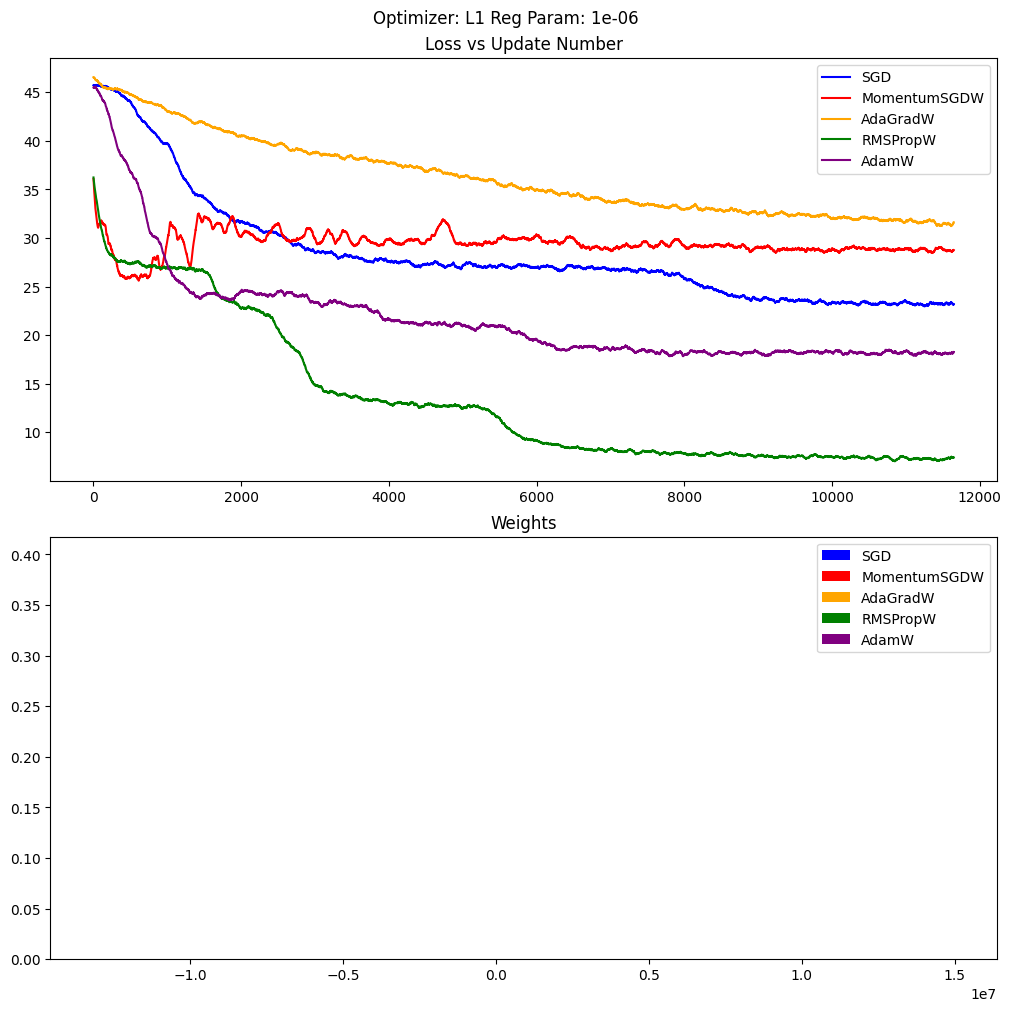

Running SGD with reg type L2 and reg param 1e-06
Epoch 0: Loss 45.25513186462454
Epoch 10: Loss 24.592137765317062
Epoch 20: Loss 24.59121013515185
Epoch 30: Loss 18.752284558094264
Epoch 40: Loss 18.617001998628073
Confusion Matrix:
[[ 917    2    0    6    1    2   18   21   12    1]
 [   0 1111    0    5    0    0    7    0   12    0]
 [  94   43    0  255    2   18  334   15  242   29]
 [  13   10    0  892    0    0   19   28   33   15]
 [   4    4    1   16    0    0  173   84   44  656]
 [  85   31    2  240    0    6   79  149  262   38]
 [  36    9    1   12    2    2  873    5   15    3]
 [  45   39    0   50    0    0    7  683   45  159]
 [  12   13    0   44    0    0   27   18  834   26]
 [  24   10    0   15    0    0   19   65   28  848]]
 {'accuracy': np.float64(0.6164), 'precision': np.float64(0.6164), 'recall': np.float64(0.6164), 'f1': np.float64(0.6164)}
Running MomentumSGDW with reg type L2 and reg param 1e-06
Epoch 0: Loss 30.518974397067723
Epoch 10: Loss 24.104

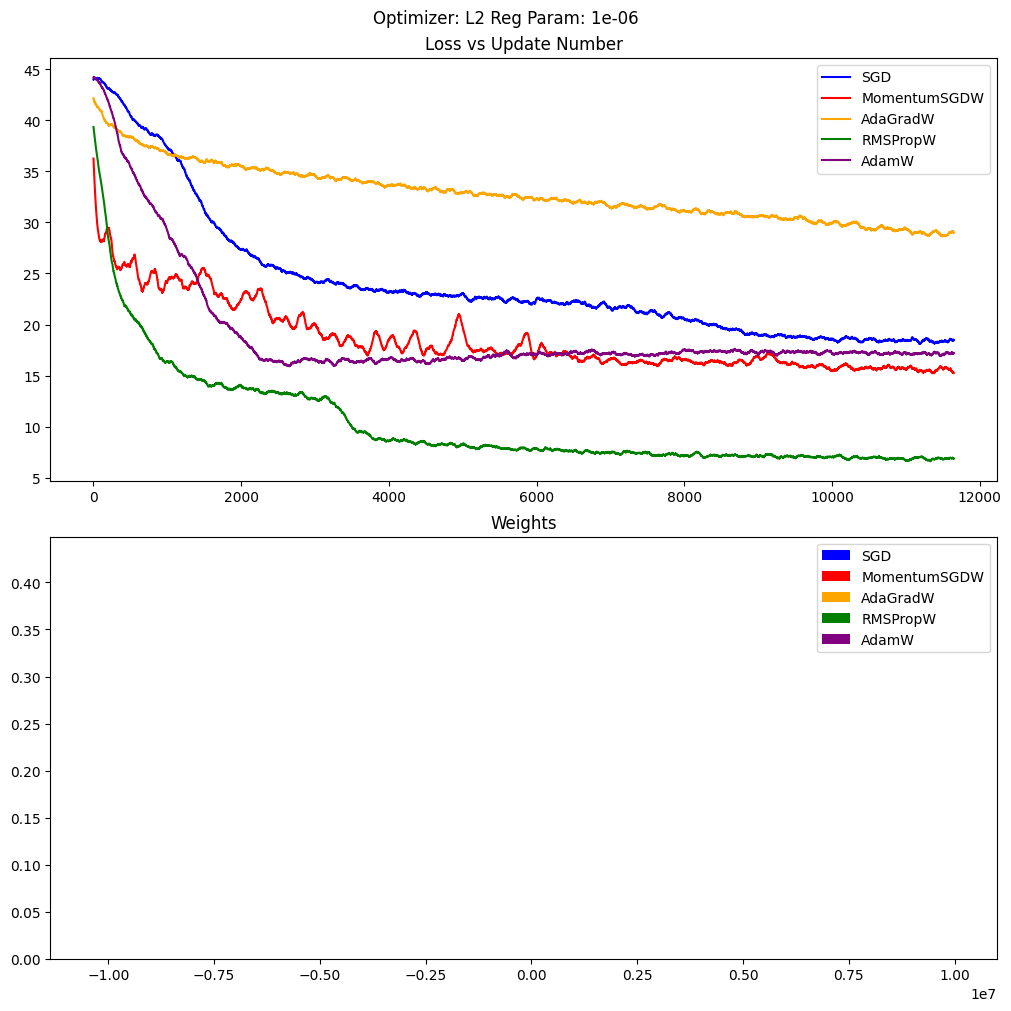

Running SGD with reg type FLinf and reg param 0.01
Epoch 0: Loss 39.963261948847155
Epoch 10: Loss 29.616775014592605
Epoch 20: Loss 22.78229877165852
Epoch 30: Loss 26.237615117934002
Epoch 40: Loss 22.29884304424544
Confusion Matrix:
[[ 939    1    0    6    0   13    0    3   13    5]
 [   0 1088    0   12    0    6    0    1   26    2]
 [ 143   83    0  252    0   13    6   79  231  225]
 [  14    5    0  861    0   41    0   27   46   16]
 [  22   17    0   23    0   17    1   40   70  792]
 [  54    9    0  142    2  495    1   15  130   44]
 [ 284   18    0   14    0   48    0   26  152  416]
 [   7   16    0   14    1    4    4  911   23   48]
 [  21   14    0   48    0   38    0   21  796   36]
 [  20   12    0   17    0   27    0   67   26  840]]
 {'accuracy': np.float64(0.593), 'precision': np.float64(0.593), 'recall': np.float64(0.593), 'f1': np.float64(0.593)}
Running MomentumSGDW with reg type FLinf and reg param 0.01
Epoch 0: Loss 43.9254958469021
Epoch 10: Loss 41.29038

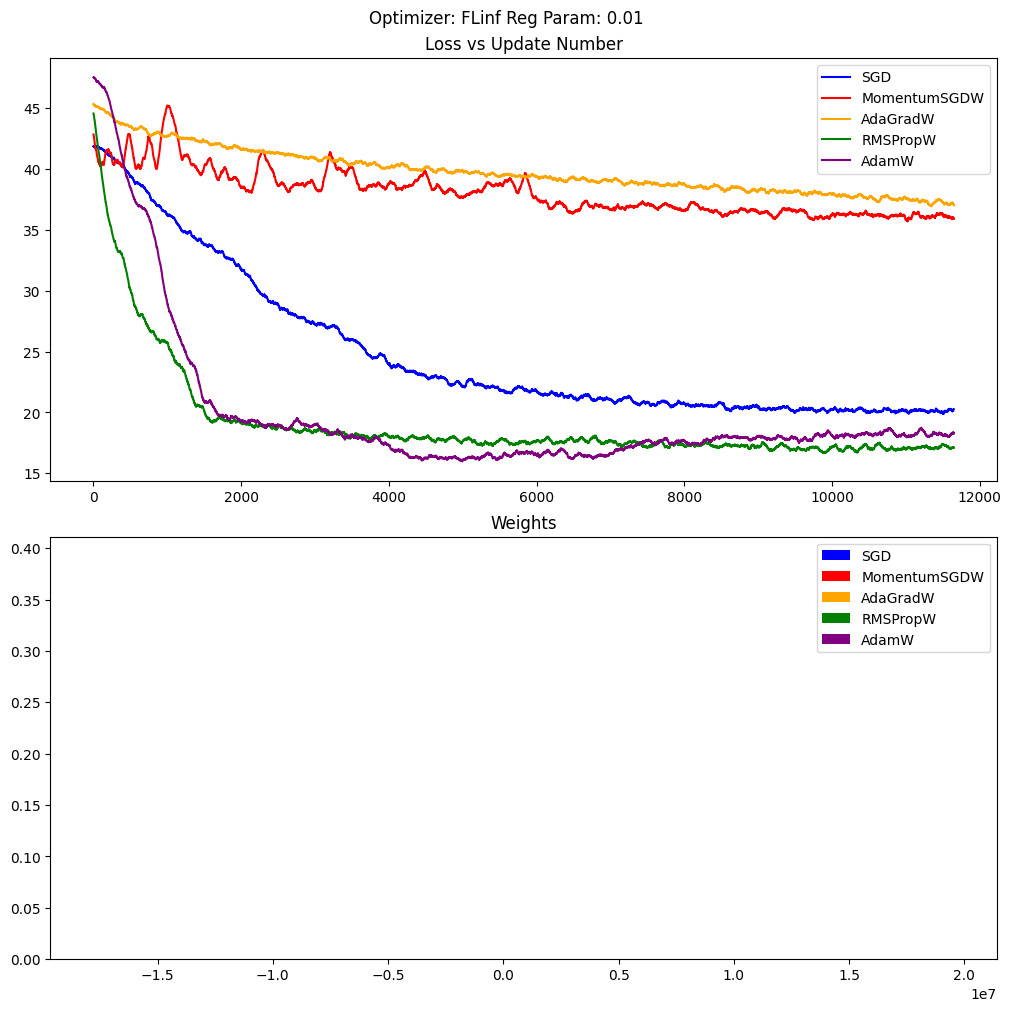

Running SGD with reg type Linf and reg param 0.001
Epoch 0: Loss 40.88219832387159
Epoch 10: Loss 25.735635046630566
Epoch 20: Loss 16.265184318199797
Epoch 30: Loss 12.63852514912881
Epoch 40: Loss 14.644668626136754
Confusion Matrix:
[[ 939    1    8    8    2    7    0    0   12    3]
 [   0 1069   11    7    2    1    0    0   45    0]
 [  17   14  883   28   18    6    0    1   52   13]
 [   6    4   36  866    4   52    0    0   27   15]
 [   6    4   12    6  863    6    0    1   26   58]
 [  71   17   15   50   29  613    0    1   72   24]
 [ 106   13  242    7  371   73    0    0  129   17]
 [  27   46   71   96   48    6    0    0   36  698]
 [  19   13   18   42   24   56    0    0  773   29]
 [  10    6   11   17   53   23    0    0   17  872]]
 {'accuracy': np.float64(0.6878), 'precision': np.float64(0.6878), 'recall': np.float64(0.6878), 'f1': np.float64(0.6878)}
Running MomentumSGDW with reg type Linf and reg param 0.001
Epoch 0: Loss 25.947848831557085
Epoch 10: Loss 16

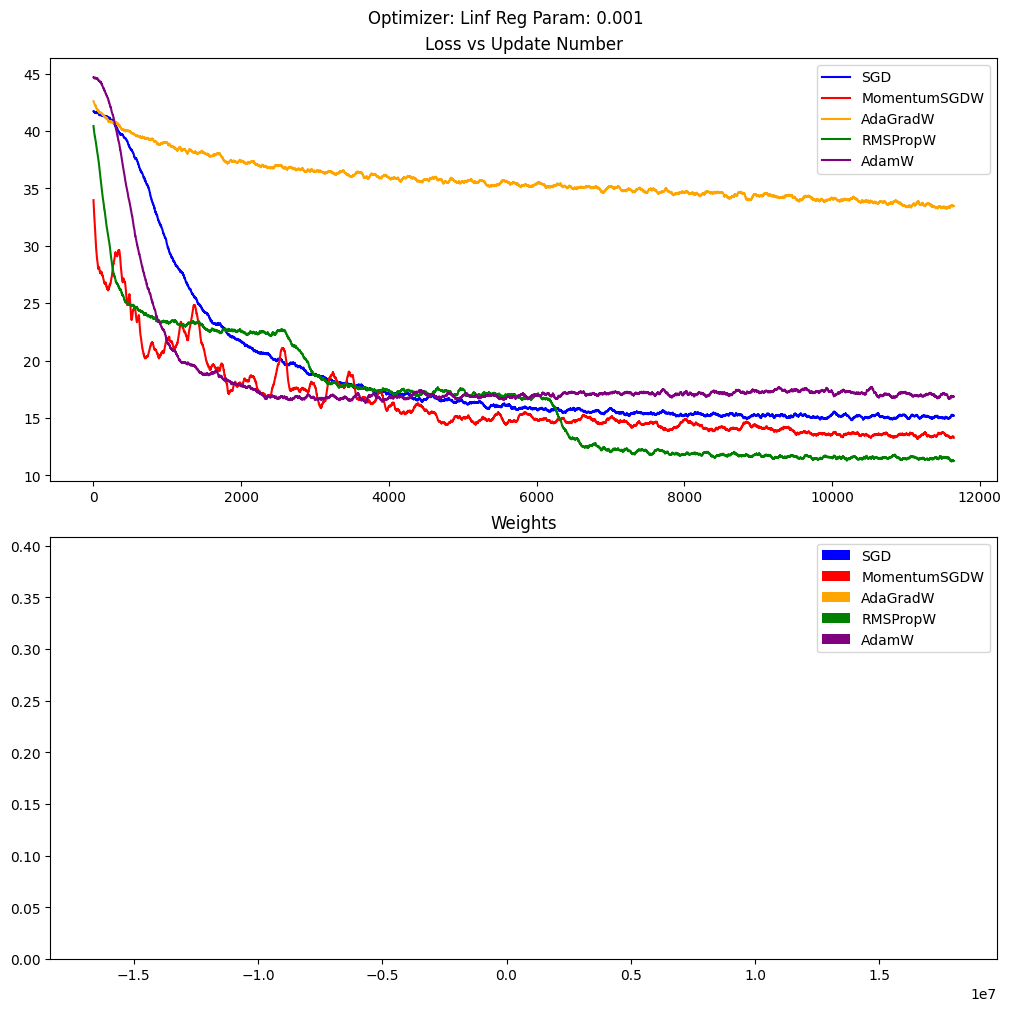

In [22]:
optimizers = [SGD, MomentumSGDW, AdaGradW, RMSPropW, AdamW]
labels = ["SGD", "MomentumSGDW", "AdaGradW", "RMSPropW", "AdamW"]
for reg_type, reg_param in zip(reg_types, reg_params):
    fig, axs = plt.subplots(2, figsize=(10,10), constrained_layout=True)
    for optimizer, color, label, kwargs in zip(optimizers, colors, labels, arglist):
        print(f"Running {label} with reg type {reg_type} and reg param {reg_param}")
        losses, params = run_test(optimizer, reg_type, reg_param, epochs=50, **kwargs)
        losses = np.array(losses)
        smoothed_losses = (losses.cumsum()[100:] - losses.cumsum()[:-100])/100
        axs[0].plot(smoothed_losses, color=color, label=label)
        axs[1].hist(params, color=(color, color), label=label, bins=15, density=True)
    axs[0].legend()
    axs[0].set_title(f"Loss vs Update Number")
    axs[1].legend()
    axs[1].set_title(f"Weights")
    fig.suptitle(f"Optimizer: {reg_type} Reg Param: {reg_param}")
    plt.show()

In [224]:
neural_net = NeuralNetwork(784, 10, activation=leaky_relu)

In [232]:
num_epochs = 50
batch_size = 256
num_steps = np.ceil(len(train_data) / batch_size) * num_epochs
warmup_steps = 0.1 * num_steps
def schedule(t):
    if t < warmup_steps:
        return t / warmup_steps
    else:
        return np.cos((t - warmup_steps) / (num_steps - warmup_steps) * np.pi / 2)

optim = MomentumSGD(neural_net.get_params(), lr=1e-5, lr_func=schedule, reg_param=1e-6, momentum=0.9)

Epoch 0: Loss 2.187835464644554
Epoch 10: Loss 1.6496139027426213
Epoch 20: Loss 2.463597218725477
Epoch 30: Loss 1.7269422907547431
Epoch 40: Loss 1.916156997455854


In [13]:
preds = softmax(neural_net(test_data)).v
get_metrics(preds, test_labels)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 784)

(array([ 2., 10., 19., 44., 58., 45., 36., 22., 14.,  6.]),
 array([-2.60378772, -2.09016426, -1.5765408 , -1.06291734, -0.54929388,
        -0.03567041,  0.47795305,  0.99157651,  1.50519997,  2.01882343,
         2.53244689]),
 <BarContainer object of 10 artists>)

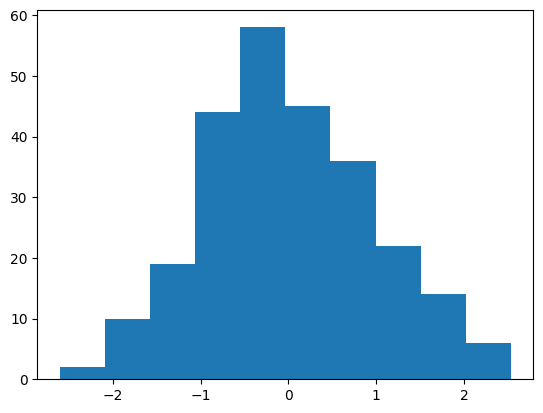

[<NpAutograd.Tensor at 0x111b34fb0>, <NpAutograd.Tensor at 0x111b06600>]

[1, 2]